In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from torch.utils.data import random_split , Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F


In [2]:
from fns import compute_entropy
from config import classes

In [3]:
cifar10h = np.load("cifar10h-probs.npy")

df=pd.DataFrame(cifar10h, columns=classes)
print(cifar10h.shape)
print(cifar10h[0])
print(cifar10h[0].sum())

assert np.allclose(cifar10h.sum(axis=1), 1.0)

(10000, 10)
[0.         0.01960784 0.01960784 0.94117647 0.         0.01960784
 0.         0.         0.         0.        ]
1.0


In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,   
    download=True,
    transform=transform
)

In [5]:
image,label = testset[0]
distribution = cifar10h[0]

print(label)
print(distribution)

3
[0.         0.01960784 0.01960784 0.94117647 0.         0.01960784
 0.         0.         0.         0.        ]


In [7]:
entropies = np.array([compute_entropy(p) for p in cifar10h])


low_idx = np.argmin(entropies)
high_idx = np.argmax(entropies)

{'airplane': np.float64(0.2511095047341411), 'automobile': np.float64(0.12824161861555036), 'bird': np.float64(0.25311775547283155), 'cat': np.float64(0.3546510222084217), 'deer': np.float64(0.40162622869044207), 'dog': np.float64(0.22678683319037535), 'frog': np.float64(0.20104638850502016), 'horse': np.float64(0.10820466531005173), 'ship': np.float64(0.15169438725799622), 'truck': np.float64(0.1519026275790706)}


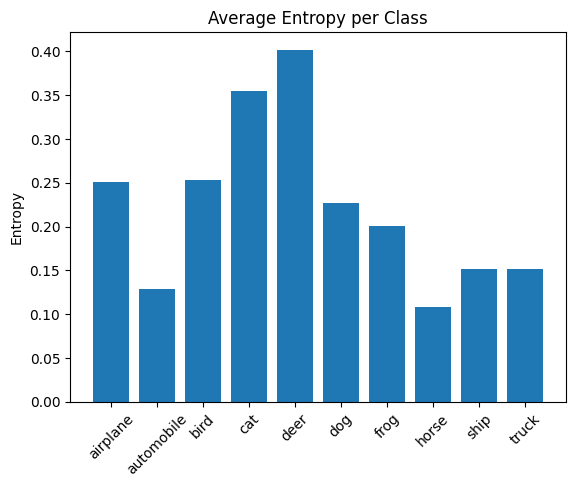

In [8]:
class_entropies = {i: [] for i in range(10)}

for i in range(len(testset)):
    _, label = testset[i]
    class_entropies[label].append(entropies[i])

avg_entropy = {classes[k]: np.mean(v) for k, v in class_entropies.items()}


print(avg_entropy)

plt.bar(avg_entropy.keys(), avg_entropy.values())
plt.xticks(rotation=45)
plt.title("Average Entropy per Class")
plt.ylabel("Entropy")
plt.show()

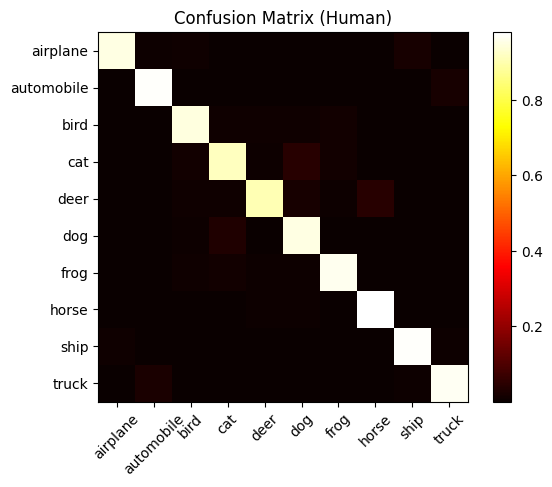

In [9]:
confusion = np.zeros((10,10))

for i in range(len(cifar10h)):
    true_label = testset[i][1]
    confusion[true_label] += cifar10h[i]

confusion = confusion / confusion.sum(axis=1, keepdims=True)

plt.imshow(confusion, cmap='hot')
plt.colorbar()
plt.xticks(range(10), classes, rotation=45)
plt.yticks(range(10), classes)
plt.title("Confusion Matrix (Human)")
plt.show()